## Step 18 — Stockout risk classification model
Step 18.0 — creation a new notebook

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
model_df = pd.read_csv("data/processed/modeling_data_features.csv")
model_df["date"] = pd.to_datetime(model_df["date"])

## Step 18.1 — inspect the target balance

In [3]:
model_df["stockout_risk_flag"].value_counts()

stockout_risk_flag
0    2925449
1      75439
Name: count, dtype: int64

In [4]:
model_df["stockout_risk_flag"].value_counts(normalize=True)

stockout_risk_flag
0    0.974861
1    0.025139
Name: proportion, dtype: float64

## Step 18.2 — prepare a clean classification dataset

In [5]:
class_df = model_df.dropna(subset=[
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_28",
    "days_until_stockout"
]).copy()

In [6]:
class_df.shape

(2219900, 37)

## Step 18.3 — choose features and target

In [7]:
feature_cols = [
    "store_nbr",
    "onpromotion",
    "transactions",
    "dcoilwtico",
    "is_holiday",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "quarter",
    "has_promotion",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28",
    "avg_daily_sales_7",
    "avg_daily_sales_14",
    "supplier_lead_time",
    "simulated_stock_on_hand",
    "reorder_point",
    "days_until_stockout",
    "reorder_urgency_score"
]

target_col = "stockout_risk_flag"

In [8]:
X = class_df[feature_cols]
y = class_df[target_col]

## Step 18.4 — time-based split

In [9]:
split_date = "2017-01-01"

train_df = class_df[class_df["date"] < split_date].copy()
test_df = class_df[class_df["date"] >= split_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1848867, 28)
Test shape: (371033, 28)


## Step 18.5 — Logistic Regression model

In [10]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred, zero_division=0)
log_recall = recall_score(y_test, log_pred, zero_division=0)
log_f1 = f1_score(y_test, log_pred, zero_division=0)
log_auc = roc_auc_score(y_test, log_prob)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression Precision:", log_precision)
print("Logistic Regression Recall:", log_recall)
print("Logistic Regression F1:", log_f1)
print("Logistic Regression ROC-AUC:", log_auc)

Logistic Regression Accuracy: 0.9990566876800716
Logistic Regression Precision: 0.9994670929922729
Logistic Regression Recall: 0.9559123343527013
Logistic Regression F1: 0.9772046372280839
Logistic Regression ROC-AUC: 0.9995651884055519


## Step 18.6 — Random Forest Classifier

In [12]:
rf_clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)
rf_prob = rf_clf.predict_proba(X_test)[:, 1]

In [13]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1:", rf_f1)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest Accuracy: 0.9997978616457296
Random Forest Precision: 1.0
Random Forest Recall: 0.9904434250764526
Random Forest F1: 0.9951987708853467
Random Forest ROC-AUC: 0.9999881832491246


## Step 18.7 — compare classification results

In [15]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1": [log_f1, rf_f1],
    "ROC_AUC": [log_auc, rf_auc]
})

classification_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.999057,0.999467,0.955912,0.977205,0.999565
1,Random Forest Classifier,0.999798,1.000000,0.990443,0.995199,0.999988


## Step 18.8 — confusion matrix

In [16]:
cm = confusion_matrix(y_test, rf_pred)
cm

array([[363185,      0],
       [    75,   7773]], dtype=int64)

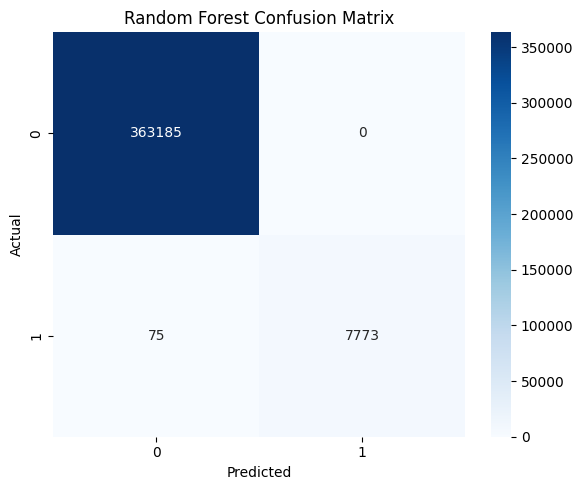

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Step 18.9 — classification report

In [18]:
print(classification_report(y_test, rf_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    363185
           1       1.00      0.99      1.00      7848

    accuracy                           1.00    371033
   macro avg       1.00      1.00      1.00    371033
weighted avg       1.00      1.00      1.00    371033



## Step 18.10 — feature importance for classification

In [19]:
clf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

clf_importance.head(10)

,feature,importance
26,days_until_stockout,0.708832
15,lag_14,0.065346
16,rolling_mean_7,0.036388
21,avg_daily_sales_7,0.029597
18,rolling_mean_28,0.027300
19,rolling_std_7,0.019569
17,rolling_mean_14,0.018743
24,simulated_stock_on_hand,0.016466
14,lag_7,0.016190
22,avg_daily_sales_14,0.014762


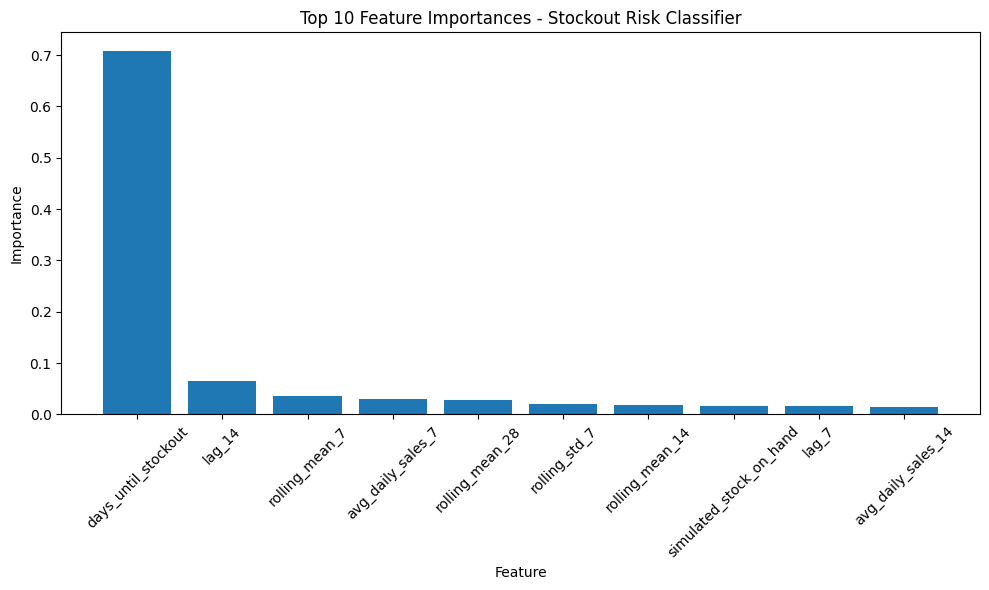

In [20]:
top_clf_features = clf_importance.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_clf_features["feature"], top_clf_features["importance"])
plt.title("Top 10 Feature Importances - Stockout Risk Classifier")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 18.11 — add predicted risk probabilities

In [21]:
test_df = test_df.copy()
test_df["predicted_stockout_flag"] = rf_pred
test_df["predicted_stockout_probability"] = rf_prob

test_df[[
    "date", "store_nbr", "family",
    "stockout_risk_flag",
    "predicted_stockout_flag",
    "predicted_stockout_probability"
]].head(20)

,date,store_nbr,family,stockout_risk_flag,predicted_stockout_flag,predicted_stockout_probability
1457,2017-01-01,1,AUTOMOTIVE,0,0,0.002111
1458,2017-01-02,1,AUTOMOTIVE,0,0,0.010009
1459,2017-01-03,1,AUTOMOTIVE,0,0,0.002440
1460,2017-01-04,1,AUTOMOTIVE,0,0,0.009983
1461,2017-01-05,1,AUTOMOTIVE,0,0,0.003860
1462,2017-01-06,1,AUTOMOTIVE,0,0,0.001988
1463,2017-01-07,1,AUTOMOTIVE,0,0,0.002187
1464,2017-01-08,1,AUTOMOTIVE,0,0,0.005475
1465,2017-01-09,1,AUTOMOTIVE,0,0,0.009707
1466,2017-01-10,1,AUTOMOTIVE,0,0,0.002156


## Step 18.12 — findings

## Step ## 18 — Stockout risk classification findings

- A time-based train/test split was used to preserve the temporal structure of the data.
- Logistic Regression provided a simple baseline classifier.
- Random Forest Classifier was used to capture non-linear relationships in stock-risk patterns.
- Evaluation focused on precision, recall, F1-score, and ROC-AUC rather than accuracy alone.
- Inventory-related engineered features such as days until stockout, reorder point, and recent demand were expected to be important predictors of stockout risk.

In [3]:
import os
os.makedirs("/data/processed", exist_ok=True)

results.to_csv("/data/processed/forecast_model_results.csv", index=False)
classification_results.to_csv("data/processed/classification_model_results.csv", index=False)

feature_importance.to_csv("data/processed/forecast_feature_importance.csv", index=False)
clf_importance.to_csv("data/processed/classification_feature_importance.csv", index=False)

daily_compare.to_csv("data/processed/daily_forecast_comparison.csv", index=False)

latest_decisions.to_csv("data/processed/latest_inventory_decisions.csv", index=False)
top_reorders.to_csv("data/processed/top_reorder_recommendations.csv", index=False)
overstock_df.to_csv("data/processed/overstock_risk_list.csv", index=False)

action_counts = latest_decisions["recommended_action"].value_counts().reset_index()
action_counts.columns = ["recommended_action", "count"]
action_counts.to_csv("data/processed/recommended_action_counts.csv", index=False)

kpi_summary = pd.DataFrame({
    "metric": [
        "total_sales",
        "average_sales",
        "num_stores",
        "num_families",
        "forecast_mae_random_forest",
        "forecast_r2_random_forest"
    ],
    "value": [
        model_df["sales"].sum(),
        model_df["sales"].mean(),
        model_df["store_nbr"].nunique(),
        model_df["family"].nunique(),
        72.685238,
        0.957601
    ]
})

kpi_summary.to_csv("data/processed/kpi_summary.csv", index=False)

latest_snapshot = latest_decisions[latest_decisions["date"] == latest_decisions["date"].max()].copy()
latest_snapshot.to_csv("data/processed/latest_dashboard_snapshot.csv", index=False)

print("All dashboard files saved successfully.")

NameError: name 'feature_importance' is not defined